In [ ]:
import ast
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 


dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills']= df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x) 

c:\Users\TOLU\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\TOLU\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Thu Mar  5 19:06:55 2026).


In [2]:
import seaborn as sns

In [4]:
df_DA_US=df[(df['job_country']== 'United States') & (df['job_title_short']== 'Data Analyst')].copy()

df_DA_US.dropna(subset=['salary_year_avg'],inplace= True)

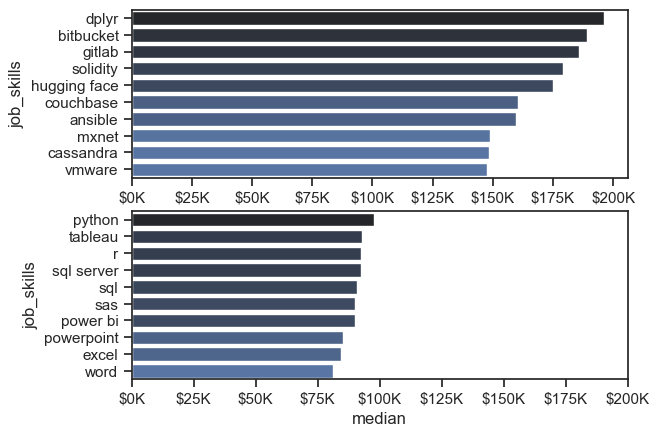

In [12]:
df_DA_US=df_DA_US.explode('job_skills')
df_DA_US_group = df_DA_US.groupby('job_skills', )['salary_year_avg'].agg(count='count', median= 'median')

df_DA_US_top_pay = df_DA_US_group.sort_values('median',ascending=False).head(10)
df_DA_US_top_skills = df_DA_US_group.sort_values('count', ascending=False).head(10).sort_values('median',ascending= False)
ig, ax = plt.subplots(2, 1)

sns.set_theme(style='ticks')
#df_DA_US_top_pay[::-1].plot(kind='barh', y= 'median',ax=ax[0],legend =False)
#df_DA_US_top_skills[::-1].plot(kind='barh',y='median', ax=ax[1],legend =False)
sns.barplot(data=df_DA_US_top_pay, x= 'median', y= df_DA_US_top_pay.index,ax=ax[0],hue='median',palette= 'dark:b_r',legend=False)
sns.barplot(data=df_DA_US_top_skills, x= 'median', y= df_DA_US_top_skills.index,ax=ax[1],hue='median',palette= 'dark:b_r',legend=False)


ax[1].set_xlim(0, 200000)
for a in ax:
    a.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
#ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.show()

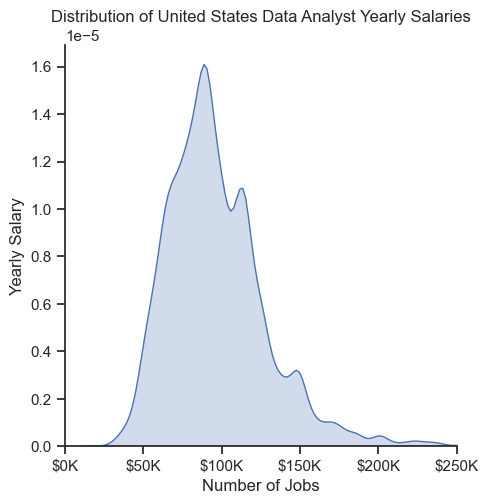

In [21]:
sns.set_theme(style='ticks')
sns.displot(df_DA_US['salary_year_avg'],kind='kde',fill=True)
#df_DA_US['salary_year_avg'].plot(kind='hist', bins= 30, edgecolor='yellow')
plt.xlim(0, 250000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.xlabel('Number of Jobs')
plt.ylabel('Yearly Salary')
plt.show()

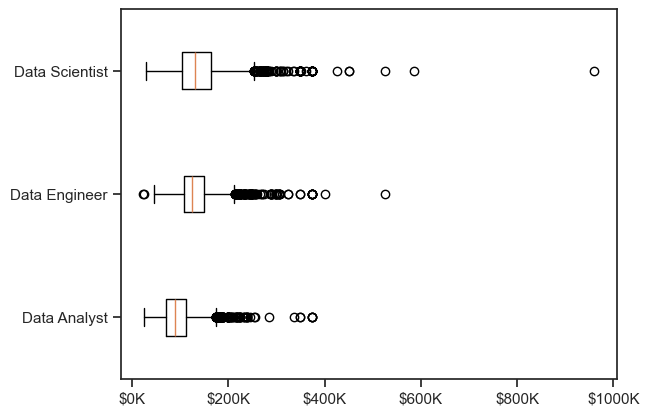

In [ ]:
job_titles= ['Data Analyst','Data Engineer','Data Scientist']

df_US=df[(df['job_country']== 'United States') & (df['job_title_short'].isin(job_titles))].copy()
df_US= df_US.dropna(subset= ['salary_year_avg'])

job_list = [df_US[df_US['job_title_short']==job_title]['salary_year_avg'] for job_title in job_titles]
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.boxplot(job_list, tick_labels= job_titles, vert=False)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

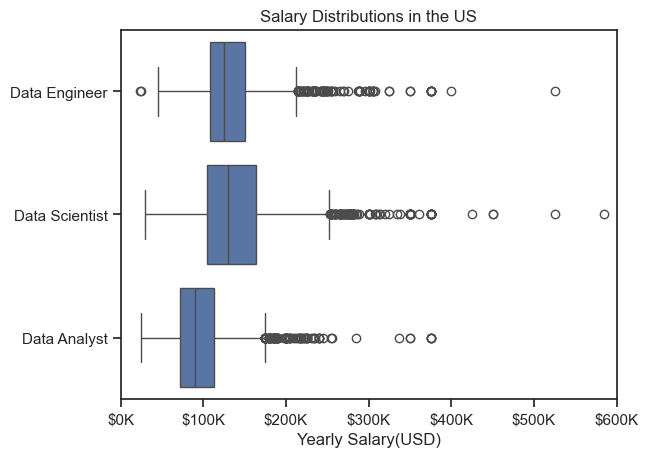

In [32]:
sns.boxplot(data=df_US, x= 'salary_year_avg', y= 'job_title_short')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
plt.title('Salary Distributions in the US')
plt.ylabel('')
plt.xlabel('Yearly Salary(USD)')
plt.xlim(0, 600000)
plt.show
